In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import networkx as nx
import torch 
from sklearn.linear_model import LogisticRegression 
import random

from torch.utils.data import DataLoader

In [2]:
project_dir = '../'

# switching to the project root directory
os.chdir(project_dir)

In [3]:
from datagen.missingData import mgraph, missing_value_dataset
from datagen.structuralModels import SEM

from models.nodags.missing_data_model import missModel
from models.nodags.missingness_mechanism import *
from models.nodags.imputation import impute_mcmc_rejection
from models.nodags.functions import gumbelSoftMLP
from models.nodags.resblock import iResBlock
from models.nodags.trainer import Trainer

from utils.error_metrics import *

## Loading and generating data

In [4]:
# load cocult dataset

chosen_genes = [2, 12, 13, 32, 33, 39, 49, 50, 54, 55]

# choose between ["cocult", "control", "ifn"]
condition = "cocult"
data_dir = f"perturb_cite_seq/{condition}"

tr_intervention_sets = np.load(os.path.join(data_dir, "training_data/intervention-set.npy"))
vl_intervention_sets = np.load(os.path.join(data_dir, "validation_data/intervention-set.npy"))

datasets = [
    np.load(os.path.join(data_dir, "training_data/dataset-{}.npy".format(i)))[:, chosen_genes] for i in range(len(tr_intervention_sets))
]

datasets += [
    np.load(os.path.join(data_dir, f"validation_data/dataset-{i}.npy"))[:, chosen_genes] for i in range(len(vl_intervention_sets))
]

datasets = [datasets[i] for i in chosen_genes]
intervention_sets = [[i] for i, _ in enumerate(chosen_genes)]



In [5]:
combined = list(zip(intervention_sets, datasets))
random.shuffle(combined)

shuffled_interventions, shuffled_datasets = zip(*combined)

In [6]:
interventional_datasets = list()
for data in shuffled_datasets:
    obs = np.ones_like(data)

    missing_ind = (np.random.binomial(1, 1.0, size=data.shape)) * (data == 0)

    R = obs * (1 - missing_ind)

    data_centered = data - np.mean(data, axis=0)
    miss_data = data_centered.copy()
    miss_data[R == 0] = np.nan
    interventional_datasets.append(
        (data_centered, R, miss_data)
    )

In [7]:
training_interventions = shuffled_interventions[:-2]
training_datasets = interventional_datasets[:-2]

testing_interventions = shuffled_interventions[-2:]
testing_datasets = interventional_datasets[-2:]

In [8]:
training_dataset = missing_value_dataset(training_datasets, training_interventions)

## Define MissNODAG model

In [9]:
causal_mech = gumbelSoftMLP(
    n_nodes=len(chosen_genes),
    lip_constant=0.9,
    activation="relu"
)

nodags = iResBlock(
    func=causal_mech,
    n_power_series=None,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nodags = nodags.to(device) 

missing_mech = identifiableMNAR(
    n_nodes=len(chosen_genes),
    learning_method="em",
    constraint_optimization="aug-lagrangian",
    C=0.01
)

missing_mech = missing_mech.to(device)

miss_model = missModel(nodags, missing_mech=missing_mech, is_mcar=True)

## Training the model

In [10]:
model_trainer = Trainer(
    miss_model=miss_model,
    lr=1e-1,
    lr_miss=1e-2,
    missingness_learn="em",
    lambda_c=1e-3,
    max_epochs=500,
    batch_size=1024,
    lambda_dag=5e-1,
    lambda_nc=1e-1
)

In [11]:
stats = model_trainer.train(
    data=training_dataset,
    print_loss=True, 
    print_interval=50,
    data_missing=True,
    min_accept_factor=0.5,
    store_grad_norm=True
)

In [19]:
with open("perturb_cite_seq/chosen_genes.csv", "r") as file:
    chosen_gene_names = file.readlines()

chosen_gene_names = [name.strip()[:-1] for name in chosen_gene_names]

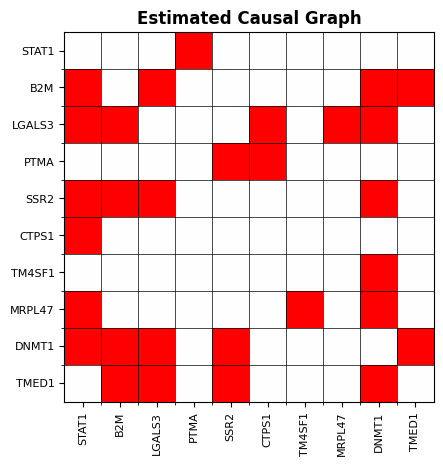

In [33]:
from PIL.ImageChops import offset
fig, axs = plt.subplots(1)

axs.imshow(nodags.get_w_adj() > 0.99, cmap='bwr', vmin=-1, vmax=1)

axs.set_xticks(range(10))
_ = axs.set_yticks(range(10))
_ = axs.set_xticklabels(chosen_gene_names, rotation=90, fontsize=8)
_ = axs.set_yticklabels(chosen_gene_names, fontsize=8)

axs.set_xticks([x + 0.5 for x in range(9)], minor=True)
axs.set_yticks([x + 0.5 for x in range(9)], minor=True)
axs.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

_ = axs.set_title("Estimated Causal Graph", fontweight=600)


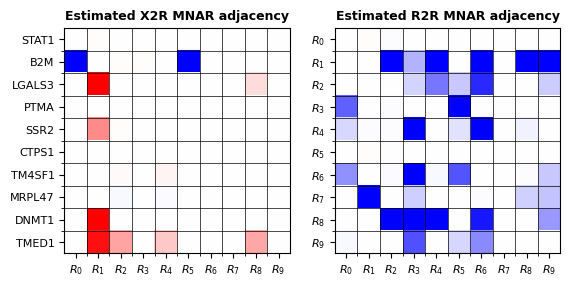

In [32]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(missing_mech.coefs_x2r.detach().cpu().numpy(), vmin=-0.5, vmax=0.5, cmap='bwr')
axs[1].imshow(missing_mech.coefs_r2r.detach().cpu().numpy(), vmin=-0.5, vmax=0.5, cmap='bwr')

axs[0].set_xticks([x + 0.5 for x in range(9)], minor=True)
axs[0].set_yticks([x + 0.5 for x in range(9)], minor=True)
axs[0].grid(which='minor', color='black', linestyle='-', linewidth=0.5)

axs[0].set_xticks(range(10))
_ = axs[0].set_yticks(range(10))
_ = axs[0].set_yticklabels(chosen_gene_names, rotation=0, fontsize=8)
_ = axs[0].set_xticklabels([f"$R_{i}$" for i in range(10)], fontsize=8)

axs[1].set_xticks(range(10))
_ = axs[1].set_yticks(range(10))
_ = axs[1].set_yticklabels([f"$R_{i}$" for i in range(10)], rotation=0, fontsize=8)
_ = axs[1].set_xticklabels([f"$R_{i}$" for i in range(10)], fontsize=8)

axs[1].set_xticks([x + 0.5 for x in range(9)], minor=True)
axs[1].set_yticks([x + 0.5 for x in range(9)], minor=True)
axs[1].grid(which='minor', color='black', linestyle='-', linewidth=0.5)

_ = axs[0].set_title("Estimated X2R MNAR adjacency", fontsize=9, fontweight=600)
_ = axs[1].set_title("Estimated R2R MNAR adjacency", fontsize=9, fontweight=600)